# Customer Churn Prediction — Deep-Dive Notebook

This version goes beyond surface-level model reporting. It shows:

- **what the models predict**
- **why Random Forest won**
- **what a feature importance value like `Complains = 0.19` actually means**
- **how complaints, status, seconds of use, and frequency of use change churn risk**
- **what can be interpreted as strong evidence vs. what should not be claimed as causation**

> **Important interpretation rule:** the model gives **predictive evidence**, not proof of causation.  
> A high importance score means the model relied heavily on that feature when separating churners from non-churners.


## How to use this notebook

1. Put **`Customer Churn.csv`** in the same folder as this notebook.  
2. Run the notebook **from top to bottom**.  
3. All charts and tables will be saved into the **`outputs/`** folder.  
4. The saved outputs can be reused directly in your presentation.

For the live demo, focus on these sections:
- **EDA**
- **Holdout test results**
- **Random Forest confusion matrix**
- **Feature importance**
- **Deep-dive interpretation**
- **Scenario sensitivity**


In [3]:
# Install packages only if needed
# Uncomment the next line if your Jupyter environment says a package is missing.
# !pip install pandas numpy matplotlib scikit-learn joblib

In [5]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from IPython.display import display
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

RANDOM_STATE = 42

In [6]:
# File paths
DATA_PATH = Path("Customer Churn.csv")

if not DATA_PATH.exists():
    candidates = [
        Path.cwd() / "Customer Churn.csv",
        Path("/mnt/data/Customer Churn.csv"),
        Path.home() / "Downloads" / "Customer Churn.csv",
    ]
    found = next((p for p in candidates if p.exists()), None)
    if found is not None:
        DATA_PATH = found

OUTPUT_DIR = Path("outputs")
(OUTPUT_DIR / "charts").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "models").mkdir(parents=True, exist_ok=True)

print("Dataset path:", DATA_PATH.resolve())
print("Output folder:", OUTPUT_DIR.resolve())

Dataset path: /Users/lovewalker/Customer Churn.csv
Output folder: /Users/lovewalker/outputs


In [9]:
def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [" ".join(str(col).split()) for col in df.columns]
    return df


def load_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = clean_column_names(df)
    redundant_cols = [col for col in ["FN", "FP"] if col in df.columns]
    if redundant_cols:
        df = df.drop(columns=redundant_cols)
        print("Dropped redundant columns:", redundant_cols)
    return df


df = load_data(DATA_PATH)
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [11]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isna().sum())

Shape: (3150, 14)

Columns:
['Call Failure', 'Complains', 'Subscription Length', 'Charge Amount', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age', 'Customer Value', 'Churn']

Missing values:
Call Failure               0
Complains                  0
Subscription Length        0
Charge Amount              0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64


## EDA 1 — Class distribution

Because churn is the minority class, **accuracy alone is not enough**.  
This is why **recall, F1-score, ROC-AUC, and the confusion matrix** matter so much in this project.


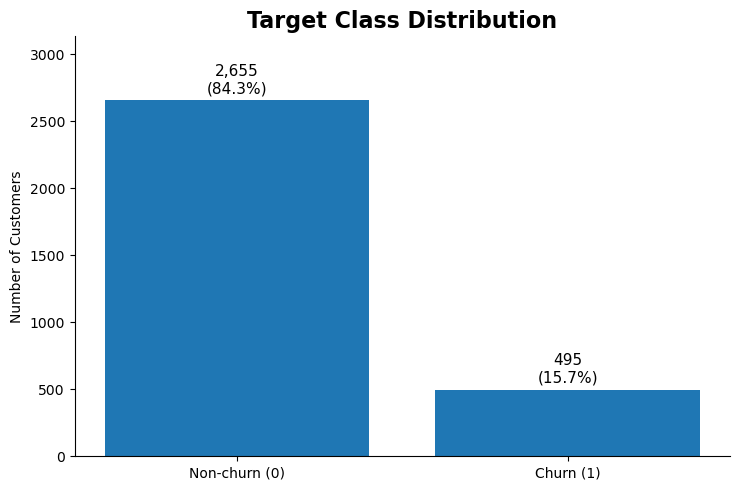

Churn
Non-churn    2655
Churn         495
Name: count, dtype: int64

In [14]:
y = df["Churn"]
class_counts = y.value_counts().sort_index()
labels = ["Non-churn (0)", "Churn (1)"]

fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.bar(labels, class_counts.values)
total = len(y)

for bar, value in zip(bars, class_counts.values):
    pct = value / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + total * 0.01,
        f"{value:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
    )

ax.set_title("Target Class Distribution", fontsize=16, weight="bold")
ax.set_ylabel("Number of Customers")
ax.set_ylim(0, max(class_counts.values) * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "charts" / "class_distribution.png", dpi=220, bbox_inches="tight")
plt.show()

display(class_counts.rename(index={0: "Non-churn", 1: "Churn"}))

## EDA 2 — Correlation with churn

This does **not** prove causation, but it helps identify which variables move most strongly with churn in the raw data.


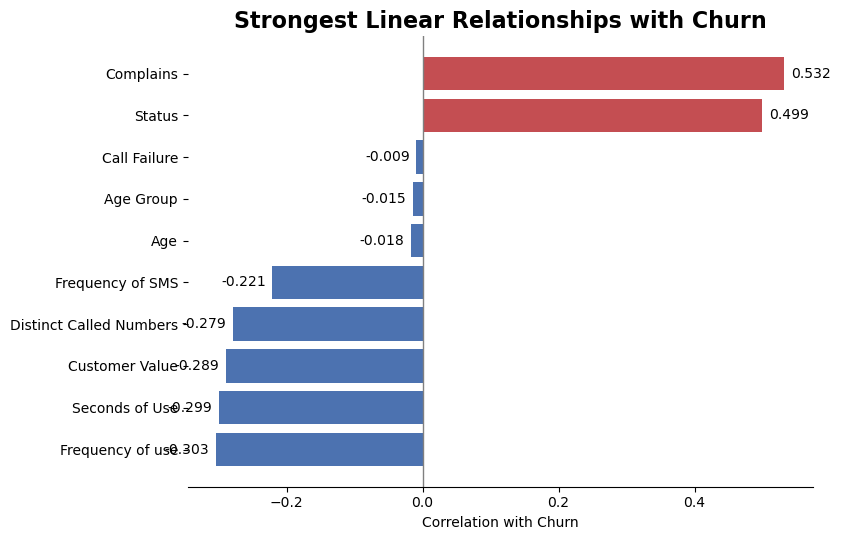

,Feature,Correlation with Churn
0,Frequency of use,-0.303
1,Seconds of Use,-0.299
2,Customer Value,-0.289
3,Distinct Called Numbers,-0.279
4,Frequency of SMS,-0.221
5,Age,-0.018
6,Age Group,-0.015
7,Call Failure,-0.009
8,Status,0.499
9,Complains,0.532


In [17]:
corr = df.corr(numeric_only=True)["Churn"].drop("Churn").sort_values()
top_corr = pd.concat([corr.head(5), corr.tail(5)]).sort_values()
top_corr_df = top_corr.reset_index()
top_corr_df.columns = ["Feature", "Correlation with Churn"]
top_corr_df.to_csv(OUTPUT_DIR / "tables" / "top_correlations_with_churn.csv", index=False)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors)

for i, v in enumerate(top_corr.values):
    ax.text(
        v + (0.01 if v >= 0 else -0.01),
        i,
        f"{v:.3f}",
        va="center",
        ha="left" if v >= 0 else "right",
        fontsize=10,
    )

ax.axvline(0, color="gray", linewidth=1)
ax.set_title("Strongest Linear Relationships with Churn", fontsize=16, weight="bold")
ax.set_xlabel("Correlation with Churn")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "charts" / "churn_correlations_bar.png", dpi=220, bbox_inches="tight")
plt.show()

top_corr_df

### Early EDA takeaway

At the raw-data level:
- **Complaints** and **Status** move positively with churn.
- **Seconds of Use**, **Frequency of Use**, **Distinct Called Numbers**, and **Customer Value** move negatively with churn.

That already suggests a business story: **dissatisfaction + declining engagement** are more important than age alone.


## Prepare features and target

In [21]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (2520, 13)
Test shape: (630, 13)


## Build models

These four models are compared **to each other** on the **same dataset** using the **same metrics**.


In [24]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

list(models.keys())

['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']

## Holdout test evaluation

In [27]:
rows = []
roc_data = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    })

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, roc_auc_score(y_test, y_prob))
    fitted_models[name] = model

metrics = pd.DataFrame(rows).sort_values("F1-score", ascending=False).reset_index(drop=True)
metrics.to_csv(OUTPUT_DIR / "tables" / "holdout_model_metrics.csv", index=False)
metrics

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.967,0.924,0.859,0.890,0.988
1,Gradient Boosting,0.948,0.875,0.778,0.824,0.974
2,Decision Tree,0.857,0.527,0.879,0.659,0.924
3,Logistic Regression,0.841,0.497,0.859,0.630,0.924


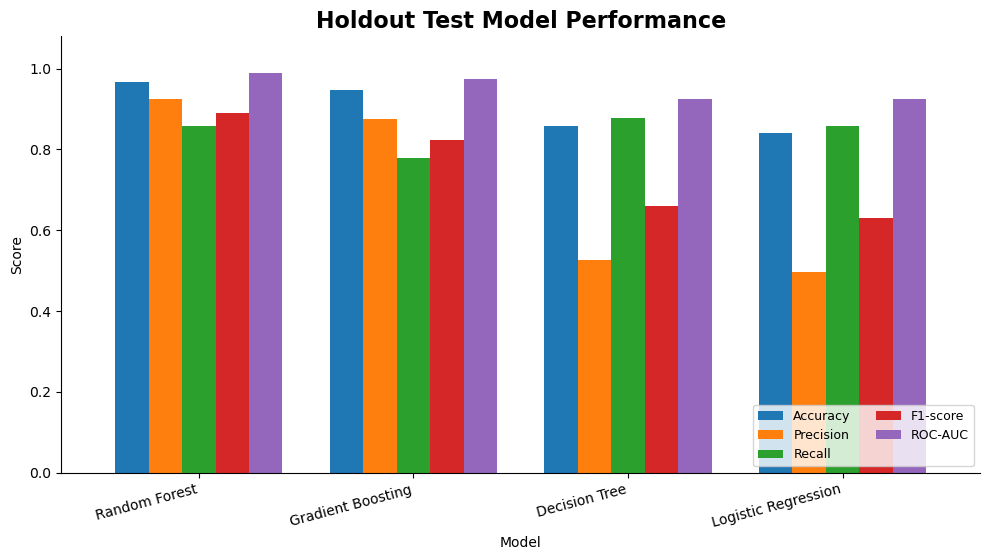

In [28]:
fig, ax = plt.subplots(figsize=(10, 5.7))
plot_df = metrics.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]]
plot_df.plot(kind="bar", ax=ax, width=0.78)
ax.set_title("Holdout Test Model Performance", fontsize=16, weight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.08)
ax.legend(loc="lower right", ncol=2, fontsize=9)
ax.set_xticklabels(plot_df.index, rotation=15, ha="right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "charts" / "model_performance.png", dpi=220, bbox_inches="tight")
plt.show()

### Holdout result takeaway

The best model is the one that gives the strongest **overall balance**, not just the highest accuracy.

In this attached dataset:
- **Random Forest** is the strongest overall model on F1-score and ROC-AUC.
- **Gradient Boosting** is the next-best nonlinear model.
- **Logistic Regression** is useful as an interpretable baseline, but it loses ground on overall balance.


## 5-fold cross-validation

This checks whether the ranking is reasonably stable beyond a single split.


In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_rows = []

for name, model in models.items():
    result = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=1)
    cv_rows.append({
        "Model": name,
        "Accuracy": result["test_accuracy"].mean(),
        "Precision": result["test_precision"].mean(),
        "Recall": result["test_recall"].mean(),
        "F1-score": result["test_f1"].mean(),
        "ROC-AUC": result["test_roc_auc"].mean(),
    })

cv_metrics = pd.DataFrame(cv_rows).sort_values("F1-score", ascending=False).reset_index(drop=True)
cv_metrics.to_csv(OUTPUT_DIR / "tables" / "cross_validation_metrics.csv", index=False)
cv_metrics

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.954,0.885,0.812,0.847,0.985
1,Gradient Boosting,0.944,0.863,0.764,0.810,0.977
2,Decision Tree,0.877,0.570,0.899,0.698,0.939
3,Logistic Regression,0.846,0.507,0.885,0.644,0.934


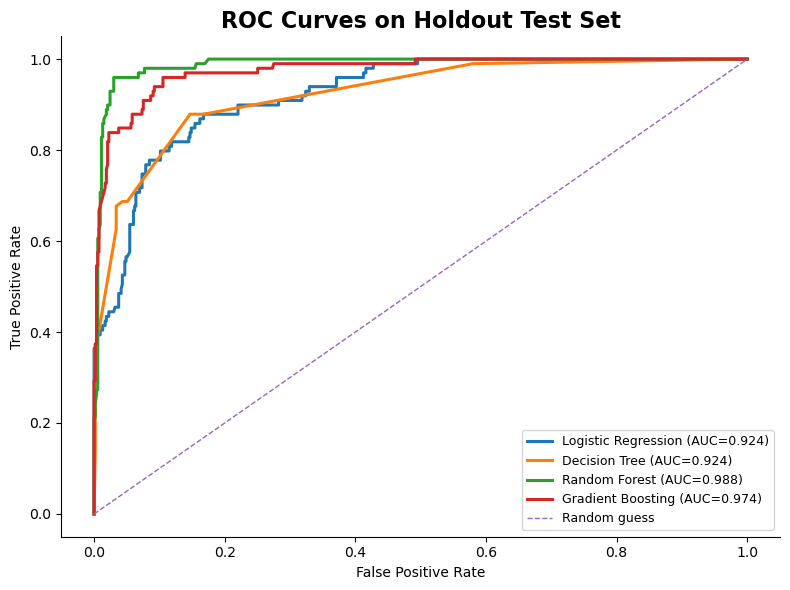

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, (fpr, tpr, auc) in roc_data.items():
    ax.plot(fpr, tpr, linewidth=2.2, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random guess")
ax.set_title("ROC Curves on Holdout Test Set", fontsize=16, weight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "charts" / "roc_curves.png", dpi=220, bbox_inches="tight")
plt.show()

## Best model: Random Forest confusion matrix

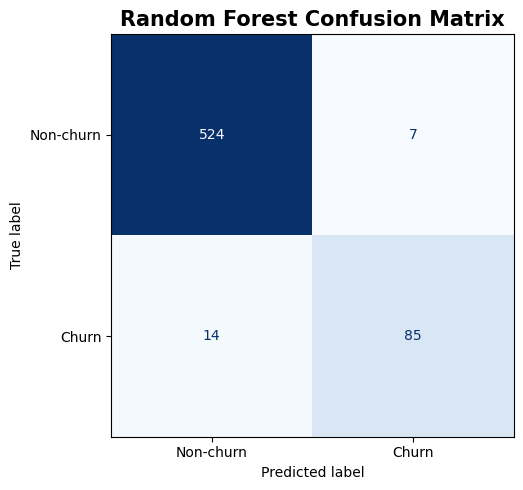

TN, FP, FN, TP = 524 7 14 85


In [36]:
best_model = fitted_models["Random Forest"]
y_pred_rf = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(5.6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-churn", "Churn"])
disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
ax.set_title("Random Forest Confusion Matrix", fontsize=15, weight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "charts" / "random_forest_confusion_matrix.png", dpi=220, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("TN, FP, FN, TP =", tn, fp, fn, tp)

### Confusion matrix takeaway

The confusion matrix tells you **what kind of mistakes** the model is making.

For churn work, false negatives matter a lot because they are the customers the company fails to catch in time.


## Best model: Feature importance

This is where the deep interpretation begins.


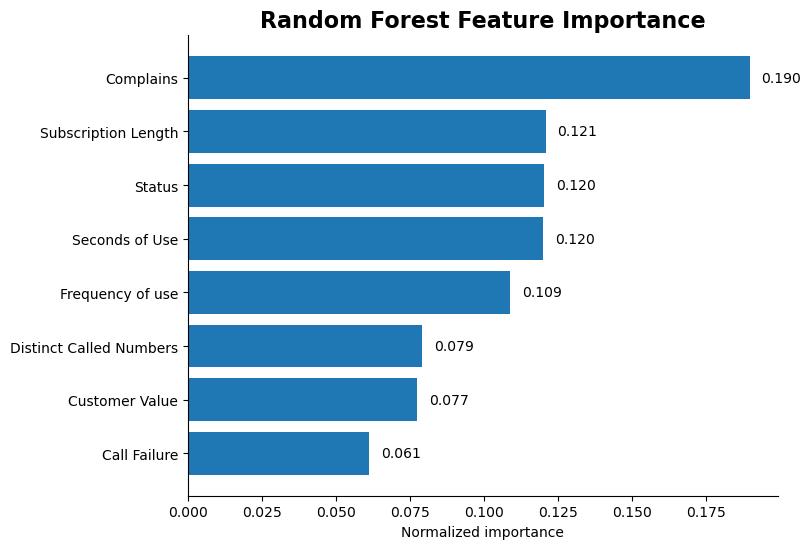

,Feature,Importance
0,Complains,0.190
1,Subscription Length,0.121
2,Status,0.120
3,Seconds of Use,0.120
4,Frequency of use,0.109
5,Distinct Called Numbers,0.079
6,Customer Value,0.077
7,Call Failure,0.061
8,Frequency of SMS,0.054
9,Age Group,0.027


In [39]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
feature_importance_df = importances.reset_index()
feature_importance_df.columns = ["Feature", "Importance"]
feature_importance_df.to_csv(OUTPUT_DIR / "tables" / "random_forest_feature_importance.csv", index=False)

top = importances.sort_values(ascending=True).tail(8)

fig, ax = plt.subplots(figsize=(8.2, 5.6))
bars = ax.barh(top.index, top.values)
for bar, value in zip(bars, top.values):
    ax.text(value + 0.004, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", fontsize=10)
ax.set_title("Random Forest Feature Importance", fontsize=16, weight="bold")
ax.set_xlabel("Normalized importance")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "charts" / "random_forest_feature_importance.png", dpi=220, bbox_inches="tight")
plt.show()

feature_importance_df

## Deep dive: What does `Complains = 0.19` actually mean?

A value like **0.19** on the Random Forest importance chart means:

- the feature contributed about **19% of the model's total split-based importance**
- the trees used that feature repeatedly because it reduced classification error
- it is a **relative importance score**, not a churn probability

So:

- it **does not** mean “19% of customers churn because of complaints”
- it **does not** mean “if a customer complains, churn probability is 19%”
- it **does not** prove causation

It **does** mean that complaint history was one of the strongest signals the model used to separate churners from non-churners.


Complains importance: 0.190
Approximate share of total normalized importance: 19.0%


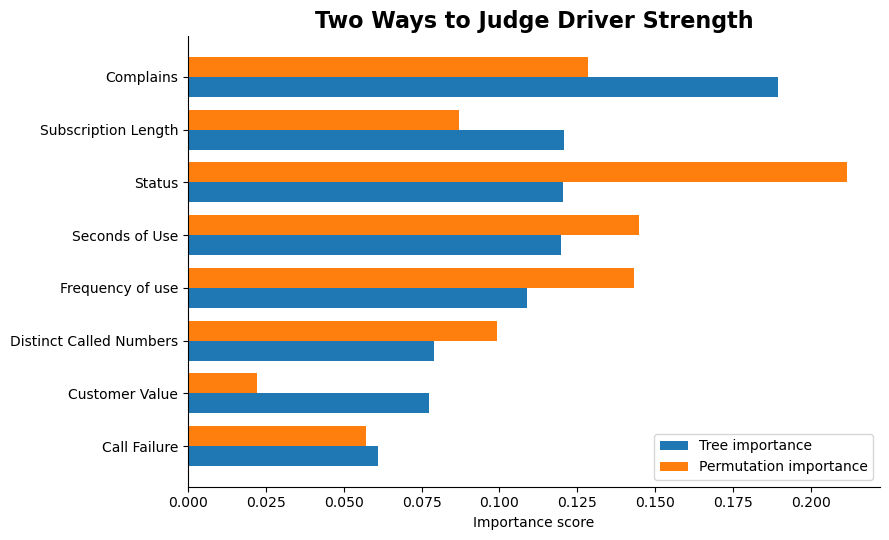

,Tree importance,Permutation importance
Complains,0.190,0.128
Subscription Length,0.121,0.087
Status,0.120,0.212
Seconds of Use,0.120,0.145
Frequency of use,0.109,0.143
Distinct Called Numbers,0.079,0.099
Customer Value,0.077,0.022
Call Failure,0.061,0.057


In [41]:
complaints_importance = float(importances["Complains"])
importance_share = complaints_importance * 100

print(f"Complains importance: {complaints_importance:.3f}")
print(f"Approximate share of total normalized importance: {importance_share:.1f}%")

perm = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring="f1"
)
perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Permutation Importance (F1 drop)": perm.importances_mean
}).sort_values("Permutation Importance (F1 drop)", ascending=False)
perm_df.to_csv(OUTPUT_DIR / "tables" / "random_forest_permutation_importance.csv", index=False)

top_features = importances.head(8).index[::-1]
compare_df = pd.DataFrame({
    "Tree importance": importances[top_features[::-1]],
    "Permutation importance": perm_df.set_index("Feature").loc[top_features[::-1], "Permutation Importance (F1 drop)"]
}).loc[top_features]

fig, ax = plt.subplots(figsize=(9, 5.5))
ypos = np.arange(len(compare_df))
width = 0.38
ax.barh(ypos - width / 2, compare_df["Tree importance"], height=width, label="Tree importance")
ax.barh(ypos + width / 2, compare_df["Permutation importance"], height=width, label="Permutation importance")
ax.set_yticks(ypos)
ax.set_yticklabels(compare_df.index)
ax.set_title("Two Ways to Judge Driver Strength", fontsize=16, weight="bold")
ax.set_xlabel("Importance score")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "charts" / "importance_comparison.png", dpi=220, bbox_inches="tight")
plt.show()

compare_df.sort_values("Tree importance", ascending=False)

## Deep dive: Complaints and status in the raw data

This is the next question after feature importance:

> **What is actually happening in the data when complaints or status change?**


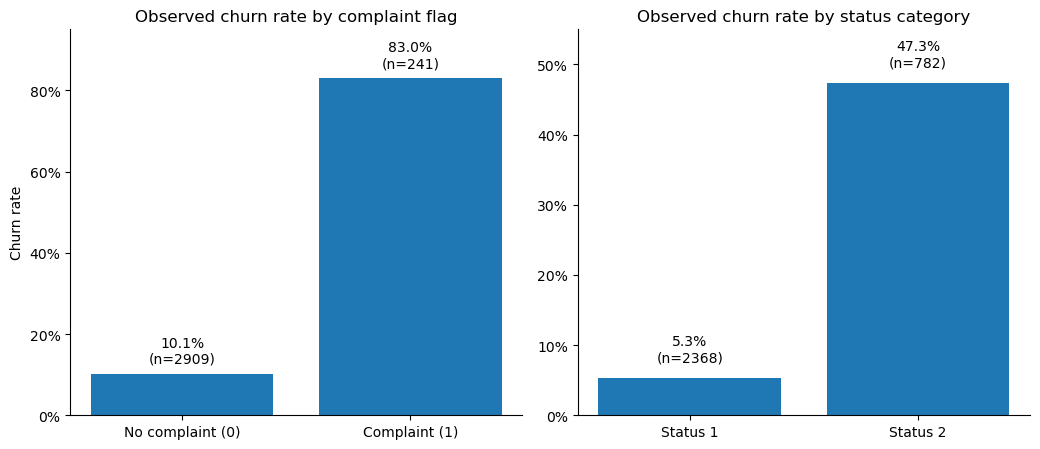

,Complains,count,sum,Churn rate (%)
0,0,2909,295,10.141
1,1,241,200,82.988


,Status,count,sum,Churn rate (%)
0,1,2368,125,5.279
1,2,782,370,47.315


In [47]:
complaints_tbl = df.groupby("Complains")["Churn"].agg(["count", "sum", "mean"]).reset_index()
complaints_tbl["Churn rate (%)"] = complaints_tbl["mean"] * 100

status_tbl = df.groupby("Status")["Churn"].agg(["count", "sum", "mean"]).reset_index()
status_tbl["Churn rate (%)"] = status_tbl["mean"] * 100

complaints_tbl.to_csv(OUTPUT_DIR / "tables" / "complaints_churn_rates.csv", index=False)
status_tbl.to_csv(OUTPUT_DIR / "tables" / "status_churn_rates.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6))

# Complaints chart
labels = ["No complaint (0)", "Complaint (1)"]
vals = complaints_tbl["Churn rate (%)"].values
bars = axes[0].bar(labels, vals)

for b, v, cnt in zip(bars, vals, complaints_tbl["count"].values):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 2, f"{v:.1f}%\n(n={cnt})", ha="center", va="bottom")

axes[0].set_title("Observed churn rate by complaint flag")
axes[0].set_ylabel("Churn rate")
axes[0].yaxis.set_major_formatter(PercentFormatter(100))
axes[0].set_ylim(0, 95)
axes[0].spines[["top", "right"]].set_visible(False)

# Status chart
labels = [f"Status {int(x)}" for x in status_tbl["Status"]]
vals = status_tbl["Churn rate (%)"].values
bars = axes[1].bar(labels, vals)

for b, v, cnt in zip(bars, vals, status_tbl["count"].values):
    axes[1].text(b.get_x() + b.get_width() / 2, v + 2, f"{v:.1f}%\n(n={cnt})", ha="center", va="bottom")

axes[1].set_title("Observed churn rate by status category")
axes[1].yaxis.set_major_formatter(PercentFormatter(100))
axes[1].set_ylim(0, 55)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "charts" / "complaints_status_churn_rates.png", dpi=220, bbox_inches="tight")
plt.show()

display(complaints_tbl[["Complains", "count", "sum", "Churn rate (%)"]])
display(status_tbl[["Status", "count", "sum", "Churn rate (%)"]])

### Why complaints matter

In this attached dataset:

- customers with **`Complains = 1`** churn at a much higher rate than customers with **`Complains = 0`**
- that is why the model keeps using this feature
- this supports the interpretation that complaint activity is a strong **dissatisfaction signal**

A careful academic interpretation is:

> complaints are a **major predictor** and a **plausible business driver** of churn,  
> but this dataset does **not** contain complaint text, so it does **not** tell us which complaint type caused the churn


## Deep dive: Why do `Seconds of Use` and `Frequency of use` matter?

The feature importance chart says the model relies on them.  
Now we want to see the practical business pattern in the data.


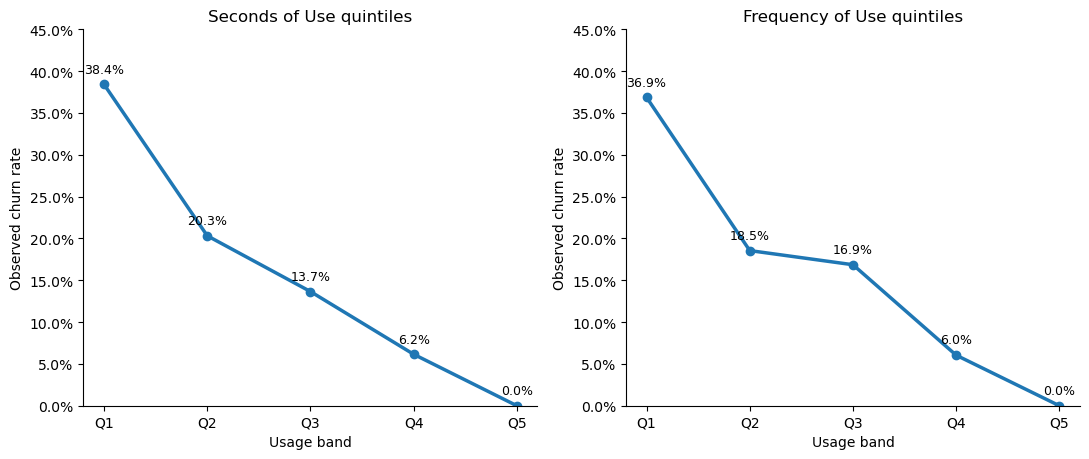

,Band,Range,count,Churn rate (%)
0,Q1,"(-0.001, 1129.0]",630,38.413
1,Q2,"(1129.0, 2388.0]",630,20.317
2,Q3,"(2388.0, 3980.8]",630,13.651
3,Q4,"(3980.8, 7023.0]",634,6.151
4,Q5,"(7023.0, 17090.0]",626,0.000


,Band,Range,count,Churn rate (%)
0,Q1,"(-0.001, 21.0]",632,36.867
1,Q2,"(21.0, 43.0]",647,18.547
2,Q3,"(43.0, 69.0]",617,16.856
3,Q4,"(69.0, 109.0]",629,6.041
4,Q5,"(109.0, 255.0]",625,0.000


In [52]:
def churn_by_quantile(data: pd.DataFrame, col: str, q: int = 5) -> pd.DataFrame:
    bins = pd.qcut(data[col], q=q, duplicates="drop")
    out = data.groupby(bins, observed=True)["Churn"].agg(["count", "mean"]).reset_index()
    out["Churn rate (%)"] = out["mean"] * 100
    out["Band"] = [f"Q{i+1}" for i in range(len(out))]
    out["Range"] = out[col].astype(str)
    return out[["Band", "Range", "count", "Churn rate (%)"]]

seconds_q = churn_by_quantile(df, "Seconds of Use", q=5)
freq_q = churn_by_quantile(df, "Frequency of use", q=5)

seconds_q.to_csv(OUTPUT_DIR / "tables" / "seconds_of_use_quintile_churn.csv", index=False)
freq_q.to_csv(OUTPUT_DIR / "tables" / "frequency_of_use_quintile_churn.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.7))

for ax, tbl, title in [
    (axes[0], seconds_q, "Seconds of Use quintiles"),
    (axes[1], freq_q, "Frequency of Use quintiles"),
]:
    ax.plot(tbl["Band"], tbl["Churn rate (%)"], marker="o", linewidth=2.5)
    for x, yv in zip(tbl["Band"], tbl["Churn rate (%)"]):
        ax.text(x, yv + 1.4, f"{yv:.1f}%", ha="center", fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("Usage band")
    ax.set_ylabel("Observed churn rate")
    ax.yaxis.set_major_formatter(PercentFormatter(100))
    ax.set_ylim(0, 45)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "charts" / "usage_quintile_churn_rates.png", dpi=220, bbox_inches="tight")
plt.show()

display(seconds_q)
display(freq_q)

### Why lower usage can lead to churn

The data show a strong pattern:

- lower **Seconds of Use** is associated with much higher churn
- lower **Frequency of use** is also associated with much higher churn

A business interpretation is:

> when customers use the service less, they may be receiving less value, disengaging, or preparing to switch

Again, this is **strong predictive evidence**, not perfect proof of causation.  
But it is exactly the kind of pattern a retention team should watch.


## Deep dive: Direction inside the model

Raw churn rates are useful, but we can also look at how the **Random Forest prediction** changes when one feature moves and the others stay in a typical range.


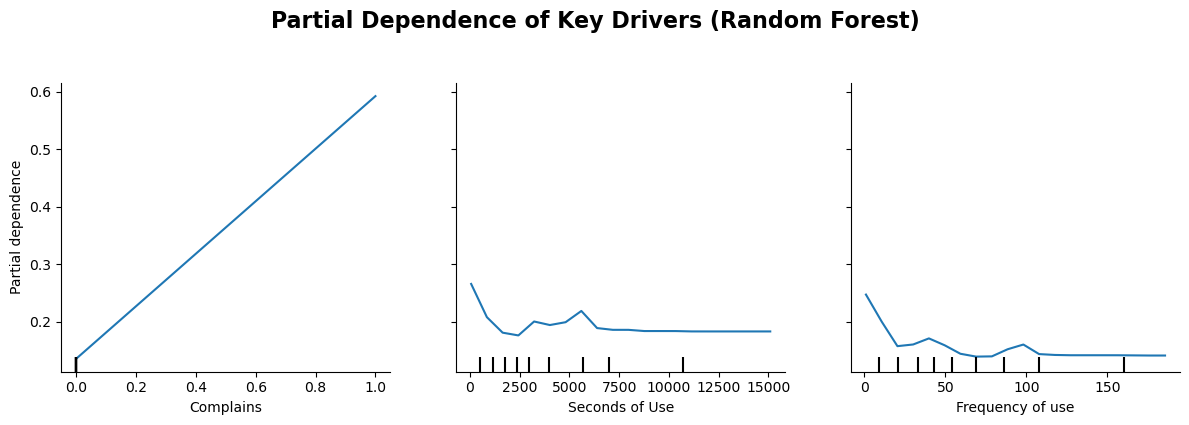

In [56]:
X_train_float = X_train.astype(float)

fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    best_model,
    X_train_float,
    ["Complains", "Seconds of Use", "Frequency of use"],
    kind="average",
    grid_resolution=20,
    ax=ax,
)
fig.suptitle("Partial Dependence of Key Drivers (Random Forest)", fontsize=16, weight="bold", y=1.05)
for a in fig.axes:
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "charts" / "partial_dependence_key_drivers.png", dpi=220, bbox_inches="tight")
plt.show()

### Explanation

- the **complaints** curve jumps sharply upward, which means the model's predicted churn risk increases when the complaint flag turns on
- the **seconds of use** and **frequency of use** curves generally slope downward, which means higher usage lowers predicted churn risk
- this helps answer the question: **“How is the model actually predicting?”**

It predicts by comparing a customer's feature pattern to the patterns learned from past churners and non-churners.


## Counterfactual scenario analysis

This is the most direct answer to:

> **“If complaints or usage change, how does the model's churn prediction change?”**


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


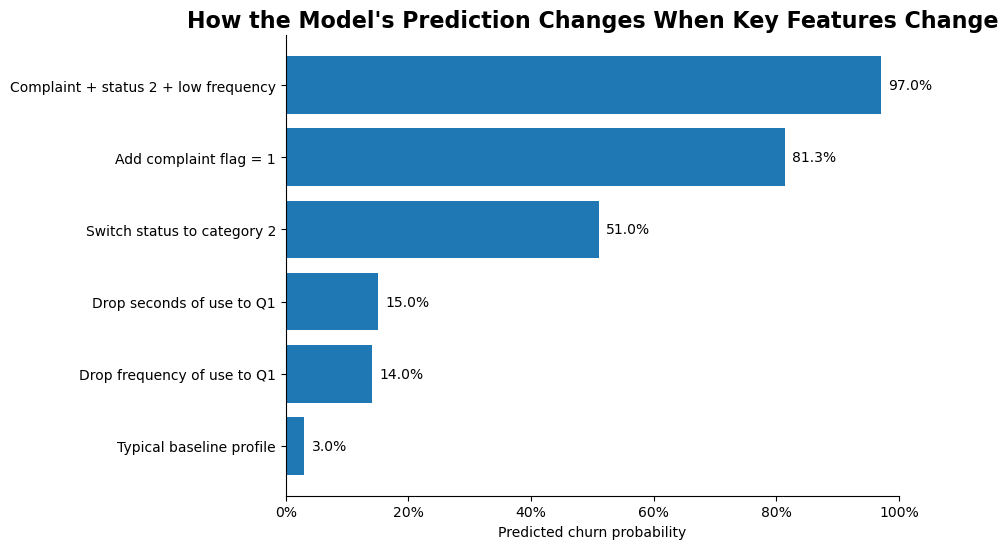

,Scenario,Predicted churn probability
0,Typical baseline profile,0.030
1,Add complaint flag = 1,0.813
2,Switch status to category 2,0.510
3,Drop seconds of use to Q1,0.150
4,Drop frequency of use to Q1,0.140
5,Complaint + status 2 + low frequency,0.970


In [60]:
baseline = {}

for col in X.columns:
    if X[col].nunique() <= 10:
        baseline[col] = float(X[col].mode()[0])
    else:
        baseline[col] = float(X[col].median())

baseline_df = pd.DataFrame([baseline])

def scenario_probability(modifications: dict) -> float:
    sample = baseline_df.copy()
    for key, value in modifications.items():
        sample[key] = float(value)
    return float(best_model.predict_proba(sample[X.columns])[:, 1][0])

scenario_rows = [
    ("Typical baseline profile", scenario_probability({})),
    ("Add complaint flag = 1", scenario_probability({"Complains": 1})),
    ("Switch status to category 2", scenario_probability({"Status": 2})),
    ("Drop seconds of use to Q1", scenario_probability({"Seconds of Use": float(X["Seconds of Use"].quantile(0.10))})),
    ("Drop frequency of use to Q1", scenario_probability({"Frequency of use": float(X["Frequency of use"].quantile(0.10))})),
    (
        "Complaint + status 2 + low frequency",
        scenario_probability({
            "Complains": 1,
            "Status": 2,
            "Frequency of use": float(X["Frequency of use"].quantile(0.10)),
        }),
    ),
]

scenario_df = pd.DataFrame(scenario_rows, columns=["Scenario", "Predicted churn probability"])
scenario_df.to_csv(OUTPUT_DIR / "tables" / "scenario_sensitivity.csv", index=False)

fig, ax = plt.subplots(figsize=(9.5, 5.6))
plot_s = scenario_df.sort_values("Predicted churn probability")
bars = ax.barh(plot_s["Scenario"], plot_s["Predicted churn probability"] * 100)

for b, v in zip(bars, plot_s["Predicted churn probability"] * 100):
    ax.text(v + 1.2, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va="center")

ax.set_title("How the Model's Prediction Changes When Key Features Change", fontsize=16, weight="bold")
ax.set_xlabel("Predicted churn probability")
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.set_xlim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "charts" / "scenario_sensitivity.png", dpi=220, bbox_inches="tight")
plt.show()

scenario_df

### Scenario takeaway

This section is useful for presentation because it translates the model into business language:

- a typical low-risk profile starts with a low predicted churn probability
- adding a **complaint flag** pushes the predicted risk much higher
- moving to **status category 2** also raises predicted risk sharply
- reducing **usage** raises risk, even when other fields stay typical
- the combination of **complaint + status change + low usage** produces the strongest risk signal

That is how the model moves from **feature importance** to **actual churn prediction**.


## Save the trained model and run a quick single-customer demo

In [64]:
model_path = OUTPUT_DIR / "models" / "random_forest_churn_model.joblib"
joblib.dump(best_model, model_path)

row_number = 27
sample_features = X.iloc[[row_number]].copy()
actual_label = int(y.iloc[row_number])
predicted_label = int(best_model.predict(sample_features)[0])
predicted_probability = float(best_model.predict_proba(sample_features)[0, 1])

print("Saved model to:", model_path.resolve())
print(f"\nRow number: {row_number}")
print(f"Actual churn label: {actual_label}")
print(f"Predicted churn label: {predicted_label}")
print(f"Predicted churn probability: {predicted_probability:.3f}")

sample_features

Saved model to: /Users/lovewalker/outputs/models/random_forest_churn_model.joblib

Row number: 27
Actual churn label: 1
Predicted churn label: 1
Predicted churn probability: 1.000


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value
27,9,1,36,0,2268,44,34,31,3,1,2,30,228.480


## Final interpretation: what the project now says

### Strong evidence from this notebook
- Random Forest is the strongest overall model on this attached CSV.
- Complaints, status, seconds of use, frequency of use, and subscription length are major predictive drivers.
- Complaint activity and lower usage are not just abstract model signals; they also line up with much higher observed churn rates.

### What you can say confidently in class
- **Complaints are one of the most powerful warning signs of churn in this dataset.**
- **Lower usage and lower engagement are strong warning signs of churn.**
- **The model uses those features to classify which customers look more like past churners.**

### What you should not overclaim
- The model does **not** prove that a complaint directly caused a customer to leave.
- The dataset does **not** contain complaint text, so it cannot say which complaint type was most harmful.
- This is a strong predictive benchmark, but not yet a full causal or production deployment study.


In [67]:
summary = f"""Customer Churn Deep-Dive Summary

Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns
Churn rate: {y.mean() * 100:.2f}%
Best model by holdout F1-score: {metrics.iloc[0]['Model']}
Accuracy: {metrics.iloc[0]['Accuracy']:.3f}
Precision: {metrics.iloc[0]['Precision']:.3f}
Recall: {metrics.iloc[0]['Recall']:.3f}
F1-score: {metrics.iloc[0]['F1-score']:.3f}
ROC-AUC: {metrics.iloc[0]['ROC-AUC']:.3f}

Top 5 Random Forest drivers:
{feature_importance_df.head(5).to_string(index=False)}

Key complaint churn rates:
{complaints_tbl[['Complains', 'Churn rate (%)']].to_string(index=False)}

Key status churn rates:
{status_tbl[['Status', 'Churn rate (%)']].to_string(index=False)}
"""

summary_path = OUTPUT_DIR / "modeling_summary.txt"
summary_path.write_text(summary)

print(summary)
print("Saved summary to:", summary_path.resolve())

Customer Churn Deep-Dive Summary

Dataset shape: 3150 rows x 14 columns
Churn rate: 15.71%
Best model by holdout F1-score: Random Forest
Accuracy: 0.967
Precision: 0.924
Recall: 0.859
F1-score: 0.890
ROC-AUC: 0.988

Top 5 Random Forest drivers:
            Feature  Importance
          Complains       0.190
Subscription Length       0.121
             Status       0.120
     Seconds of Use       0.120
   Frequency of use       0.109

Key complaint churn rates:
 Complains  Churn rate (%)
         0          10.141
         1          82.988

Key status churn rates:
 Status  Churn rate (%)
      1           5.279
      2          47.315

Saved summary to: /Users/lovewalker/outputs/modeling_summary.txt
